In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/My Drive/Colab Notebooks/Python-Ejercicios/Data/'

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(path + "dataset_trafico_FINAL_LIMPIO.csv")

In [ ]:
df.head()

,timestamp_iso,nombre_zona,nombre_archivo,hora_del_dia,dia_semana,es_fin_de_semana,es_hora_punta,es_festivo,temperatura_c,descripcion_tiempo,humedad_porcentaje,velocidad_viento_ms,precipitacion_mm_h,coches_detectados,motos_detectadas,vehiculos_grandes_detectados,unidades_de_congestion,tipo_trafico_nuevo
0,2025-10-27T12:46:20.382445,A6_LasRosas,A6_LasRosas_20251027_124620.jpg,12,0,0,Valle,0,15.08,cielo claro,47,1.54,0.0,8,0,0,8.0,MEDIO
1,2025-10-27T12:46:21.028230,AC11_Coruna,AC11_Coruna_20251027_124621.jpg,12,0,0,Valle,0,15.77,algo de nubes,63,3.09,0.0,18,0,1,20.0,ALTO
2,2025-10-27T12:46:21.331232,A6_Universitaria,A6_Universitaria_20251027_124621.jpg,12,0,0,Valle,0,15.32,cielo claro,47,1.54,0.0,23,0,3,29.0,ALTO
3,2025-10-27T12:46:21.765866,A6_Pozuelo,A6_Pozuelo_20251027_124621.jpg,12,0,0,Valle,0,15.99,cielo claro,48,1.03,0.0,13,0,3,19.0,ALTO
4,2025-10-27T12:46:22.104490,A6_LaNavata,A6_LaNavata_20251027_124622.jpg,12,0,0,Valle,0,14.63,cielo claro,46,2.00,0.0,16,0,2,20.0,ALTO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3211 entries, 0 to 3210
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp_iso                 3211 non-null   object 
 1   nombre_zona                   3211 non-null   object 
 2   nombre_archivo                3211 non-null   object 
 3   hora_del_dia                  3211 non-null   int64  
 4   dia_semana                    3211 non-null   int64  
 5   es_fin_de_semana              3211 non-null   int64  
 6   es_hora_punta                 3211 non-null   object 
 7   es_festivo                    3211 non-null   int64  
 8   temperatura_c                 3211 non-null   float64
 9   descripcion_tiempo            3211 non-null   object 
 10  humedad_porcentaje            3211 non-null   int64  
 11  velocidad_viento_ms           3211 non-null   float64
 12  precipitacion_mm_h            3211 non-null   float64
 13  coc

In [ ]:
df = df.sample(frac = 1) #vale para mezclarlos de forma random, (muy util)
df.head()

,timestamp_iso,nombre_zona,nombre_archivo,hora_del_dia,dia_semana,es_fin_de_semana,es_hora_punta,es_festivo,temperatura_c,descripcion_tiempo,humedad_porcentaje,velocidad_viento_ms,precipitacion_mm_h,coches_detectados,motos_detectadas,vehiculos_grandes_detectados,unidades_de_congestion,tipo_trafico_nuevo
2466,2025-10-31T19:00:57.906994,A6_Pozuelo,A6_Pozuelo_20251031_190057.jpg,19,4,0,Punta Tarde,0,14.49,nubes dispersas,81,1.54,0.0,9,0,0,9.0,MEDIO
1652,2025-10-30T18:58:04.382452,A6_LaNavata,A6_LaNavata_20251030_185804.jpg,18,3,0,Punta Tarde,0,12.71,nubes,68,2.01,0.0,3,0,1,5.0,MEDIO
380,2025-10-27T23:11:14.624550,A6_Universitaria,A6_Universitaria_20251027_231114.jpg,23,0,0,Valle,0,8.83,cielo claro,72,1.54,0.0,4,0,0,4.0,MEDIO
1151,2025-10-30T04:39:17.794537,A6_ColladoVillalba,A6_ColladoVillalba_20251030_043917.jpg,4,3,0,Valle,0,10.68,algo de nubes,80,0.57,0.0,1,0,0,1.0,BAJO
3030,2025-11-01T11:09:27.571679,A6_Coruna,A6_Coruna_20251101_110927.jpg,11,5,1,Valle,0,13.77,nubes,88,2.06,0.0,18,0,0,18.0,ALTO


In [ ]:
len(df)

3211

In [ ]:
df.drop(columns=["nombre_archivo"], inplace=True)

['timestamp_iso', 'nombre_zona', 'hora_del_dia', 'dia_semana', 'es_fin_de_semana', 'es_hora_punta', 'es_festivo', 'temperatura_c', 'descripcion_tiempo', 'humedad_porcentaje', 'velocidad_viento_ms', 'precipitacion_mm_h', 'coches_detectados', 'motos_detectadas', 'vehiculos_grandes_detectados', 'tipo_trafico_nuevo']


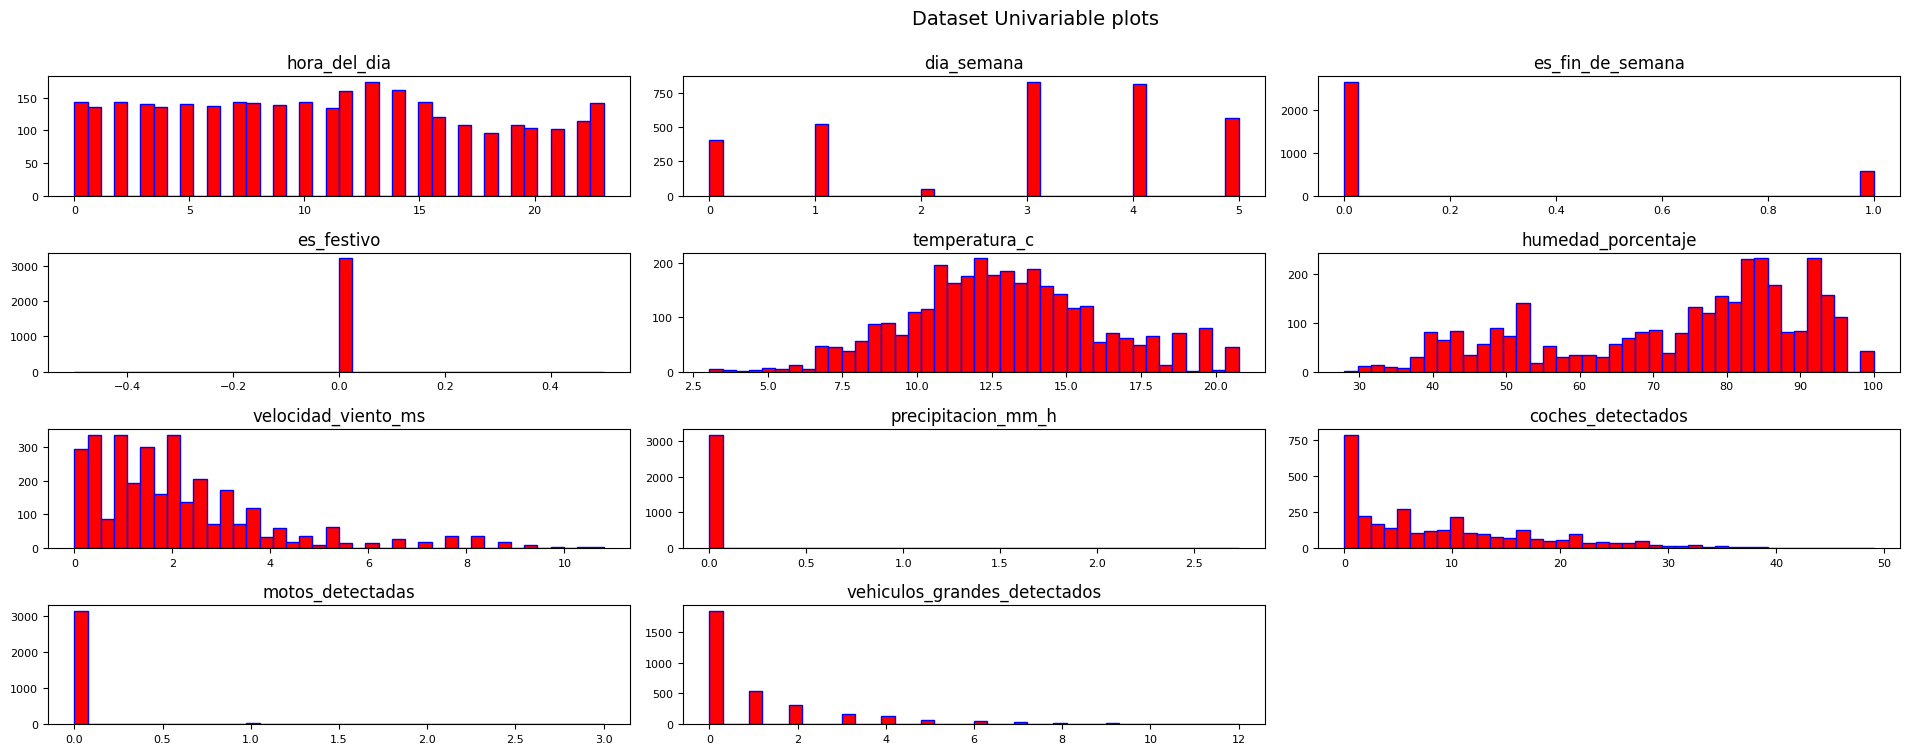

In [ ]:
# Extrayendo nuestra variable objetivo 'Utilizada'
# y creando una lista de características útiles de las variables dependientes

from matplotlib import pyplot as plt

target = 'unidades_de_congestion'
features_list = list(df.columns)
features_list.remove(target)
print(features_list)

df[features_list].hist(bins=40, edgecolor='b', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='red')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('Dataset Univariable plots', x=0.65, y=1.25, fontsize=14);

In [ ]:
pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport

# Crear el informe (puedes ajustar el título)
profile = ProfileReport(
    df,
    title="Análisis Exploratorio del Dataset de Bioseñales y Tabaquismo",
    explorative=True,  # activa más análisis
    minimal=False      # para incluir TODAS las métricas (simetría, varianza, etc.)
)

# Mostrar el informe en Colab
profile

# Exportar a HTML en tu carpeta del proyecto
output_path = path + "profile_report.html"
profile.to_file(output_path)

print(f"✅ Informe generado correctamente: {output_path}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 22.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Informe generado correctamente: /content/drive/My Drive/Colab Notebooks/Python-Ejercicios/Data/profile_report.html


In [ ]:
df_transformed = df.copy()

In [ ]:
cols_to_drop = ['es_festivo', 'timestamp_iso']

In [ ]:
df_transformed = df_transformed.drop(columns=cols_to_drop)

In [ ]:
traffic_mapping = {
    'BAJO': 0,
    'MEDIO': 1,
    'ALTO': 2
}
df_transformed['tipo_trafico_nuevo'] = df_transformed['tipo_trafico_nuevo'].map(traffic_mapping)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols_to_encode = ['nombre_zona', 'es_hora_punta', 'descripcion_tiempo']

In [ ]:
mappings = {}

for col in cols_to_encode:
    # Ajustamos el codificador y transformamos la columna
    df_transformed[col] = le.fit_transform(df_transformed[col])

    # Guardamos la referencia del mapeo {Texto: Número}
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [ ]:
print("--- Mapeos Generados ---")
for col, mapping in mappings.items():
    print(f"\n{col}:")
    print(mapping)

print("\n--- Primeras filas transformadas ---")
print(df_transformed.head())

# Guardar el dataset listo para EDA numérico / Machine Learning
df_transformed.to_csv('dataset_trafico_numeric.csv', index=False)

--- Mapeos Generados ---

nombre_zona:
{'A6_ColladoVillalba': 0, 'A6_Coruna': 1, 'A6_LaNavata': 2, 'A6_LasRosas': 3, 'A6_Pozuelo': 4, 'A6_Universitaria': 5, 'AC11_Coruna': 6}

es_hora_punta:
{'Punta Mañana': 0, 'Punta Mediodía': 1, 'Punta Tarde': 2, 'Valle': 3}

descripcion_tiempo:
{'algo de nubes': 0, 'bruma': 1, 'cielo claro': 2, 'llovizna': 3, 'llovizna ligera': 4, 'lluvia ligera': 5, 'lluvia moderada': 6, 'muy nuboso': 7, 'niebla': 8, 'nubes': 9, 'nubes dispersas': 10}

--- Primeras filas transformadas ---
      nombre_zona  hora_del_dia  dia_semana  es_fin_de_semana  es_hora_punta  \
2466            4            19           4                 0              2   
1652            2            18           3                 0              2   
380             5            23           0                 0              3   
1151            0             4           3                 0              3   
3030            1            11           5                 1              3   

   

In [ ]:
df_transformed.head()

,nombre_zona,hora_del_dia,dia_semana,es_fin_de_semana,es_hora_punta,temperatura_c,descripcion_tiempo,humedad_porcentaje,velocidad_viento_ms,precipitacion_mm_h,coches_detectados,motos_detectadas,vehiculos_grandes_detectados,unidades_de_congestion,tipo_trafico_nuevo
2466,4,19,4,0,2,14.49,10,81,1.54,0.0,9,0,0,9.0,1
1652,2,18,3,0,2,12.71,9,68,2.01,0.0,3,0,1,5.0,1
380,5,23,0,0,3,8.83,2,72,1.54,0.0,4,0,0,4.0,1
1151,0,4,3,0,3,10.68,0,80,0.57,0.0,1,0,0,1.0,0
3030,1,11,5,1,3,13.77,9,88,2.06,0.0,18,0,0,18.0,2


In [ ]:
nan_per_column = df_transformed.isna().sum()
print(nan_per_column)

nombre_zona                     0
hora_del_dia                    0
dia_semana                      0
es_fin_de_semana                0
es_hora_punta                   0
temperatura_c                   0
descripcion_tiempo              0
humedad_porcentaje              0
velocidad_viento_ms             0
precipitacion_mm_h              0
coches_detectados               0
motos_detectadas                0
vehiculos_grandes_detectados    0
unidades_de_congestion          0
tipo_trafico_nuevo              0
dtype: int64


In [ ]:
duplicados = df.duplicated()  # Devuelve una serie booleana indicando si cada fila es un duplicado o no
df[duplicados]  # Muestra solo las filas duplicadas

,timestamp_iso,nombre_zona,hora_del_dia,dia_semana,es_fin_de_semana,es_hora_punta,es_festivo,temperatura_c,descripcion_tiempo,humedad_porcentaje,velocidad_viento_ms,precipitacion_mm_h,coches_detectados,motos_detectadas,vehiculos_grandes_detectados,unidades_de_congestion,tipo_trafico_nuevo


In [ ]:
import numpy as np

# Transformar Hora (ciclo de 24h)
df_transformed['hora_sin'] = np.sin(2 * np.pi * df_transformed['hora_del_dia'] / 24)
df_transformed['hora_cos'] = np.cos(2 * np.pi * df_transformed['hora_del_dia'] / 24)

# Transformar Día de la semana (ciclo de 7 días)
df_transformed['dia_sin'] = np.sin(2 * np.pi * df_transformed['dia_semana'] / 7)
df_transformed['dia_cos'] = np.cos(2 * np.pi * df_transformed['dia_semana'] / 7)

# Ahora puedes eliminar las columnas originales 'hora_del_dia' y 'dia_semana' si vas a usar modelos lineales

In [ ]:
def tratar_outliers_iqr(df, columnas):
    df_clean = df.copy()

    for col in columnas:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Opción: Capping (Topear los valores)
        # Si es mayor que el límite superior, lo igualamos al límite superior
        df_clean[col] = np.where(
            df_clean[col] > limite_superior,
            limite_superior,
            df_clean[col]
        )

        # Si es menor que el límite inferior, lo igualamos al límite inferior
        df_clean[col] = np.where(
            df_clean[col] < limite_inferior,
            limite_inferior,
            df_clean[col]
        )

    return df_clean

# Aplicamos esto a las columnas numéricas que escalaste
columnas_con_outliers = ['velocidad_viento_ms', 'coches_detectados']
df_transformed = tratar_outliers_iqr(df_transformed, columnas_con_outliers)

print("Outliers tratados mediante Capping.")

Outliers tratados mediante Capping.


In [ ]:
# 1. Interacción Clima-Tráfico
# Multiplicamos la intensidad de lluvia por los coches detectados.

df_transformed['riesgo_clima_trafico'] = df_transformed['precipitacion_mm_h'] * df_transformed['coches_detectados']

# 2. Flag de Hora Punta (Manual)

df_transformed['es_hora_punta'] = df_transformed['hora_del_dia'].apply(
    lambda x: 1 if (7 <= x <= 9) or (18 <= x <= 20) else 0
)

# 3. Fin de semana
# Usamos el dia de la semana original antes de borrarlo (0=Lunes, 6=Domingo)
df_transformed['es_finde'] = df_transformed['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Se excluye la variable objetivo (Target) y columnas de texto
features_vif = df_transformed[['temperatura_c', 'humedad_porcentaje',
                               'velocidad_viento_ms', 'coches_detectados',
                               'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos']]

# Crear dataframe del VIF
vif_data = pd.DataFrame()
vif_data["feature"] = features_vif.columns
vif_data["VIF"] = [variance_inflation_factor(features_vif.values, i)
                   for i in range(len(features_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

               feature        VIF
0        temperatura_c  19.331404
1   humedad_porcentaje  14.091390
2  velocidad_viento_ms   6.281160
3    coches_detectados   3.730746
5             hora_cos   1.971599
7              dia_cos   1.743145
4             hora_sin   1.437635
6              dia_sin   1.307572


In [ ]:
# 1. Eliminar la columna con VIF excesivo

df_transformed = df_transformed.drop(columns=['temperatura_c'], errors='ignore')

print("Variable 'temperatura_c' eliminada por multicolinealidad alta.")

# 2. Definir las columnas finales para escalar

cols_to_scale = ['humedad_porcentaje', 'velocidad_viento_ms', 'coches_detectados']


if 'condicion_adversa' in df_transformed.columns:
    cols_to_scale.append('condicion_adversa')

# 3. Escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_transformed[cols_to_scale] = scaler.fit_transform(df_transformed[cols_to_scale])

print("Datos escalados correctamente. ¡Listos para entrenar!")

Variable 'temperatura_c' eliminada por multicolinealidad alta.
Datos escalados correctamente. ¡Listos para entrenar!


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['humedad_porcentaje', 'velocidad_viento_ms', 'coches_detectados']

df_transformed[cols_to_scale] = scaler.fit_transform(df_transformed[cols_to_scale])

In [ ]:
pip install pycaret

In [ ]:
df_transformed.head()


,nombre_zona,hora_del_dia,dia_semana,es_fin_de_semana,es_hora_punta,descripcion_tiempo,humedad_porcentaje,velocidad_viento_ms,precipitacion_mm_h,coches_detectados,motos_detectadas,vehiculos_grandes_detectados,unidades_de_congestion,tipo_trafico_nuevo,hora_sin,hora_cos,dia_sin,dia_cos,riesgo_clima_trafico,es_finde
2466,4,19,4,0,1,10,0.447727,-0.316716,0.0,-0.005833,0,0,9.0,1,-0.965926,2.588190e-01,-0.433884,-0.900969,0.0,0
1652,2,18,3,0,1,9,-0.296222,-0.000825,0.0,-0.699505,0,1,5.0,1,-1.000000,-1.836970e-16,0.433884,-0.900969,0.0,0
380,5,23,0,0,0,2,-0.067314,-0.316716,0.0,-0.583893,0,0,4.0,1,-0.258819,9.659258e-01,0.000000,1.000000,0.0,0
1151,0,4,3,0,0,0,0.390501,-0.968663,0.0,-0.930729,0,0,1.0,0,0.866025,5.000000e-01,0.433884,-0.900969,0.0,0
3030,1,11,5,1,0,9,0.848315,0.032781,0.0,1.034676,0,0,18.0,2,0.258819,-9.659258e-01,-0.974928,-0.222521,0.0,1


In [ ]:
# 1. Definir la lista de TODAS las variables que son "mediciones del momento" (Fuga de datos)
variables_prohibidas = [
    'coches_detectados',
    'motos_detectadas',
    'vehiculos_grandes_detectados',
    'unidades_de_congestion',
    'tipo_trafico_nuevo',
    'riesgo_clima_trafico',
    'categoria_trafico',  # El target original
    'target_encoded'      # El target codificado
]



variables_texto = ['nombre_zona', 'descripcion_tiempo']

# Lista total a eliminar de X
cols_a_borrar = variables_prohibidas + variables_texto

# 2. Limpiar X
# Solo borramos las que realmente existan en tu DataFrame
cols_existentes_borrar = [c for c in cols_a_borrar if c in df_transformed.columns]

X_final = df_transformed.drop(cols_existentes_borrar, axis=1)
y_final = df_transformed['tipo_trafico_nuevo'] # Asegúrate de que esta columna existe

print(f"Columnas finales para el modelo (SIN TRAMPAS): \n{X_final.columns.tolist()}")


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
from IPython.display import display

# 3. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# 4. Entrenar y Comparar (Versión Simplificada)
print("\n--- Entrenando con datos honestos ---")

modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados = []

for nombre, modelo in modelos.items():
    try:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        resultados.append({"Modelo": nombre, "Accuracy": acc, "F1-Score": f1})
    except Exception as e:
        print(f"Error en {nombre}: {e}")

display(pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False))

Columnas finales para el modelo (SIN TRAMPAS): 
['hora_del_dia', 'dia_semana', 'es_fin_de_semana', 'es_hora_punta', 'humedad_porcentaje', 'velocidad_viento_ms', 'precipitacion_mm_h', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'es_finde']

--- Entrenando con datos honestos ---


,Modelo,Accuracy,F1-Score
2,Gradient Boosting,0.724728,0.722146
1,Random Forest,0.716952,0.715614
0,Regresión Logística,0.645412,0.641425


/tmp/ipython-input-755677791.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


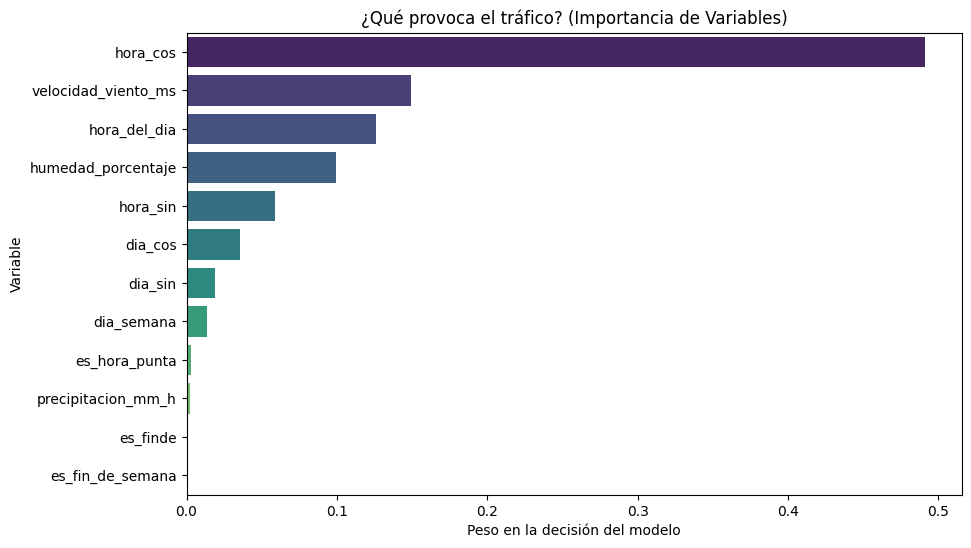

                Feature  Importancia
8              hora_cos     0.490845
5   velocidad_viento_ms     0.149152
0          hora_del_dia     0.125921
4    humedad_porcentaje     0.099359
7              hora_sin     0.058669
10              dia_cos     0.035619
9               dia_sin     0.019106
1            dia_semana     0.013816
3         es_hora_punta     0.002833
6    precipitacion_mm_h     0.002255
11             es_finde     0.001308
2      es_fin_de_semana     0.001118


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recuperamos el mejor modelo (Gradient Boosting o Random Forest)

from sklearn.ensemble import GradientBoostingClassifier

# Usamos los mismos parámetros que antes
best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(X_train, y_train)

# 2. Extraer la importancia
importancia = best_model.feature_importances_
nombres_col = X_train.columns

# Crear un DataFrame para ordenar los datos
df_importancia = pd.DataFrame({'Feature': nombres_col, 'Importancia': importancia})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Visualizar
plt.figure(figsize=(10, 6))

sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')

plt.title('¿Qué provoca el tráfico? (Importancia de Variables)')
plt.xlabel('Peso en la decisión del modelo')
plt.ylabel('Variable')
plt.show()

# Mostramos los valores numéricos
print(df_importancia)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Definir el modelo base
gb = GradientBoostingClassifier(random_state=42)

# 2. Definir la "rejilla" de parámetros a probar

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

print("Iniciando búsqueda de hiperparámetros (esto puede tardar unos minutos)...")

# 3. Configurar la búsqueda (Cross Validation de 3 pliegues)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=1, scoring='f1_weighted')

# 4. Entrenar con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# 5. Ver los resultados
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación F1 en validación: {grid_search.best_score_:.4f}")

# 6. Probar el modelo optimizado en el Test Set
best_model_optimized = grid_search.best_estimator_
y_pred_opt = best_model_optimized.predict(X_test)

print("\n--- Reporte del Modelo Optimizado ---")
print(classification_report(y_test, y_pred_opt))

Iniciando búsqueda de hiperparámetros (esto puede tardar unos minutos)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Mejores parámetros encontrados: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Mejor puntuación F1 en validación: 0.7248

--- Reporte del Modelo Optimizado ---
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       227
           1       0.59      0.58      0.59       208
           2       0.76      0.80      0.78       208

    accuracy                           0.73       643
   macro avg       0.73      0.73      0.73       643
weighted avg       0.73      0.73      0.73       643



<Figure size 800x600 with 0 Axes>

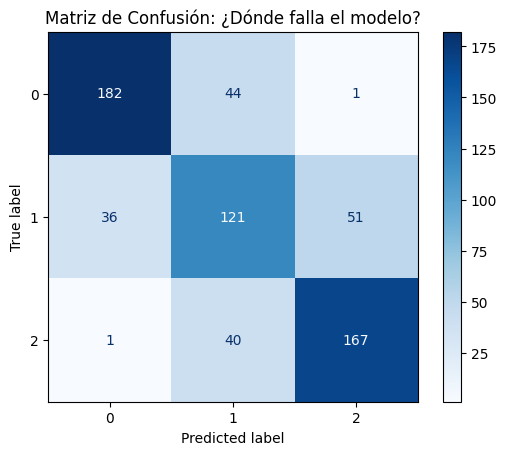

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generar predicciones con el mejor modelo
y_pred = best_model_optimized.predict(X_test)

# 2. Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# 3. Visualizarla bonita
plt.figure(figsize=(8, 6))

disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusión: ¿Dónde falla el modelo?')
plt.show()